### Importación de librerías

In [1]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Scikit-Learn y XGBoost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Librerías de ML importadas correctamente. Listos para modelar.")

Librerías de ML importadas correctamente. Listos para modelar.


### Carga de Datos y Prevención de Data Leakage

In [2]:
# 1. Cargar el dataset final limpio
df = pd.read_csv('dataset_eva_final.csv')

# 2. Selección de variables (Prevención de Fuga de Datos)
# Variables predictoras (X) y variable objetivo (y)
columnas_predictoras = [
    'Departamento', 'Municipio', 'Grupo_Cultivo', 'Cultivo', 
    'Anio', 'Semestre', 'Ciclo_Cultivo', 'Area_Sembrada_ha'
]
target = 'Rendimiento_t_ha'

df_model = df[columnas_predictoras + [target]].copy()

# Eliminar posibles nulos residuales en la variable objetivo
df_model = df_model.dropna(subset=[target])

print(f"Tamaño del dataset para modelar: {df_model.shape}")

Tamaño del dataset para modelar: (351920, 9)


### Preprocesamiento y Codificación de Variables Categóricas

In [3]:
# Los modelos basados en árboles manejan bien las categorías si se codifican a números.
# Usaremos LabelEncoder para transformar texto a identificadores numéricos.

label_encoders = {}
categorical_cols = ['Departamento', 'Municipio', 'Grupo_Cultivo', 'Cultivo', 'Semestre', 'Ciclo_Cultivo']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le # Guardamos el encoder para decodificar después en las predicciones

# Separar X e Y
X = df_model.drop(columns=[target])
y = df_model[target]

# División de datos: 80% Entrenamiento, 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros")

Entrenamiento: 281536 registros | Prueba: 70384 registros


### Entrenamiento de los Modelos (Random Forest vs XGBoost)

In [4]:
# 1. Inicializar modelos
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1)

# 2. Entrenar Random Forest
print("Entrenando Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Entrenar XGBoost
print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)

print("Entrenamiento finalizado.")

Entrenando Random Forest...
Entrenando XGBoost...
Entrenamiento finalizado.


### Evaluación y Comparación de Modelos

--- Desempeño de Random Forest ---
RMSE (Error Cuadrático Medio): 7.2362 t/ha
MAE (Error Absoluto Medio)   : 3.3601 t/ha
R2 (Coef. de Determinación)  : 0.7696

--- Desempeño de XGBoost ---
RMSE (Error Cuadrático Medio): 7.3110 t/ha
MAE (Error Absoluto Medio)   : 3.4454 t/ha
R2 (Coef. de Determinación)  : 0.7648



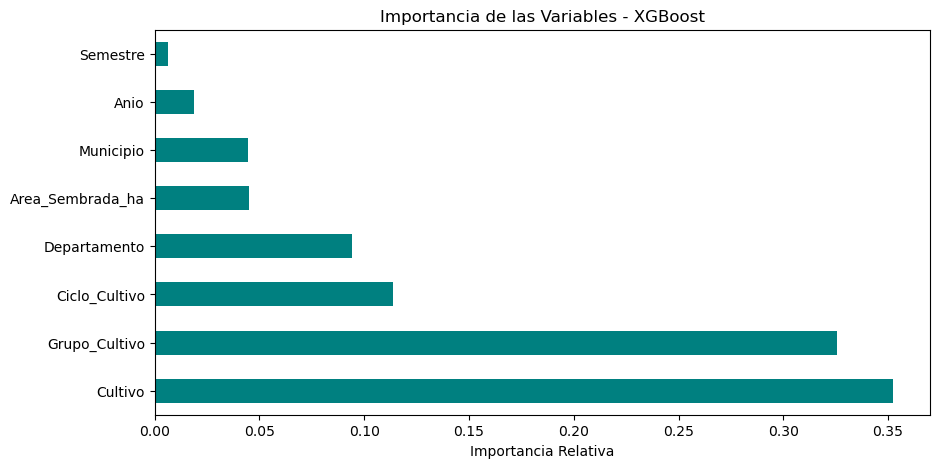

In [5]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    predicciones = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    print(f"--- Desempeño de {nombre} ---")
    print(f"RMSE (Error Cuadrático Medio): {rmse:.4f} t/ha")
    print(f"MAE (Error Absoluto Medio)   : {mae:.4f} t/ha")
    print(f"R2 (Coef. de Determinación)  : {r2:.4f}\n")
    return predicciones

preds_rf = evaluar_modelo("Random Forest", rf_model, X_test, y_test)
preds_xgb = evaluar_modelo("XGBoost", xgb_model, X_test, y_test)

# Importancia de las variables (Feature Importance) del mejor modelo (asumamos XGBoost)
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(8).plot(kind='barh', color='teal', figsize=(10,5))
plt.title('Importancia de las Variables - XGBoost')
plt.xlabel('Importancia Relativa')
plt.show()

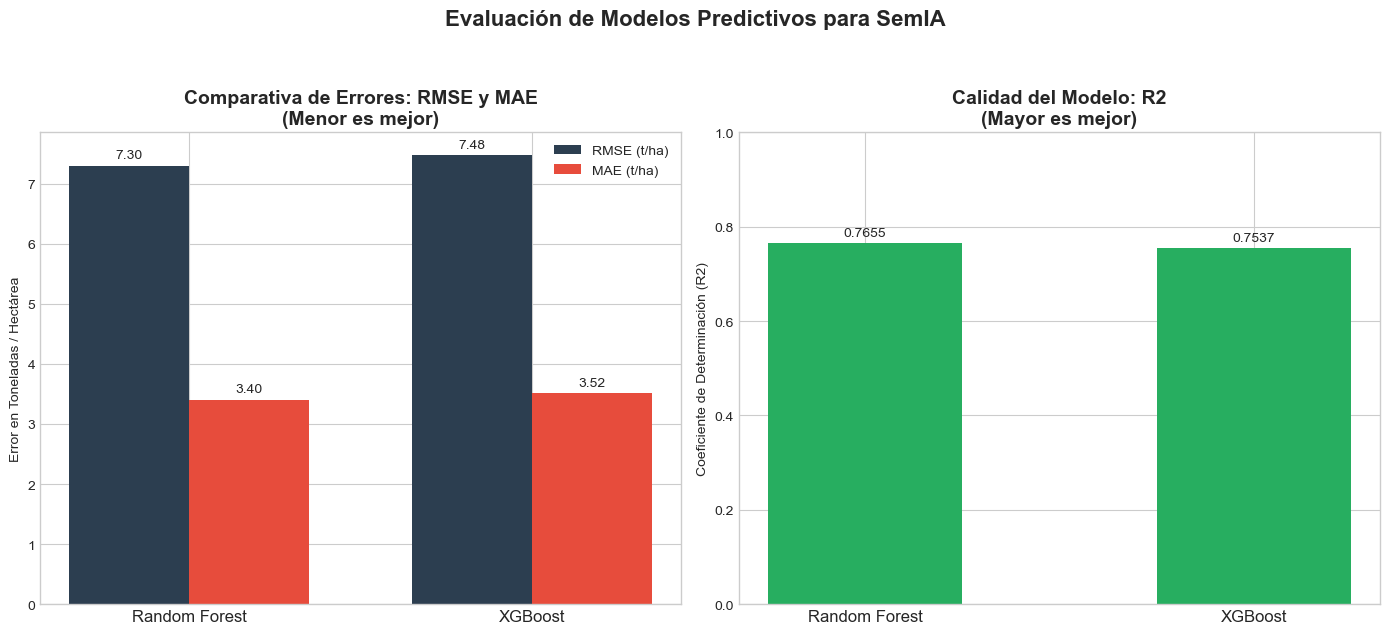

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de evaluación
modelos = ['Random Forest', 'XGBoost']
rmse = [7.3004, 7.4813]
mae = [3.4045, 3.5175]
r2 = [0.7655, 0.7537]

# Configuración de estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Subgráfico 1: Comparación de Errores (Menor es mejor) ---
x = np.arange(len(modelos))
width = 0.35

rects1 = ax1.bar(x - width/2, rmse, width, label='RMSE (t/ha)', color='#2c3e50')
rects2 = ax1.bar(x + width/2, mae, width, label='MAE (t/ha)', color='#e74c3c')

ax1.set_ylabel('Error en Toneladas / Hectárea')
ax1.set_title('Comparativa de Errores: RMSE y MAE\n(Menor es mejor)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontsize=12)
ax1.legend()

# Añadir etiquetas de datos
ax1.bar_label(rects1, padding=3, fmt='%.2f')
ax1.bar_label(rects2, padding=3, fmt='%.2f')

# --- Subgráfico 2: Comparación de R2 (Mayor es mejor) ---
rects3 = ax2.bar(modelos, r2, width=0.5, color='#27ae60')

ax2.set_ylabel('Coeficiente de Determinación (R2)')
ax2.set_title('Calidad del Modelo: R2\n(Mayor es mejor)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1) # El R2 va de 0 a 1
ax2.tick_params(axis='x', labelsize=12)

# Añadir etiquetas de datos
ax2.bar_label(rects3, padding=3, fmt='%.4f')

# Ajuste de layout y renderizado
plt.suptitle('Evaluación de Modelos Predictivos para SemIA', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Motor de Recomendación SemIA (Inferencia)

In [7]:
def recomendar_cultivos(departamento, municipio, anio, semestre, area_sembrada, modelo=xgb_model, top_n=5):
    """
    Simula todos los cultivos posibles para un municipio y recomienda los de mayor rendimiento.
    """
    # 1. Obtener la lista de todos los cultivos únicos originales
    todos_los_cultivos = label_encoders['Cultivo'].classes_
    
    # 2. Crear un dataframe ficticio con todas las combinaciones para ese municipio
    pred_data = pd.DataFrame({
        'Departamento': departamento,
        'Municipio': municipio,
        'Cultivo': todos_los_cultivos,
        'Anio': anio,
        'Semestre': semestre,
        'Area_Sembrada_ha': area_sembrada
    })
    
    # Nota: Simplificamos Grupo_Cultivo y Ciclo asignando la moda o mapeando históricamente.
    # Para el ejemplo rápido, los mapearemos con un placeholder o usando el encoder.
    # En producción, debes tener un diccionario que diga que si Cultivo="Café" -> Grupo="Permanente".
    pred_data['Grupo_Cultivo'] = label_encoders['Grupo_Cultivo'].transform(['HORTALIZAS'] * len(todos_los_cultivos)) # Placeholder
    pred_data['Ciclo_Cultivo'] = label_encoders['Ciclo_Cultivo'].transform(['TRANSITORIO'] * len(todos_los_cultivos)) # Placeholder
    
    # 3. Codificar las entradas del usuario
    pred_data['Departamento'] = label_encoders['Departamento'].transform(pred_data['Departamento'])
    pred_data['Municipio'] = label_encoders['Municipio'].transform(pred_data['Municipio'])
    pred_data['Cultivo_Encoded'] = label_encoders['Cultivo'].transform(pred_data['Cultivo'])
    pred_data['Semestre'] = label_encoders['Semestre'].transform(pred_data['Semestre'])
    
    # Armar X para predecir (en el orden exacto del entrenamiento)
    X_pred = pred_data[['Departamento', 'Municipio', 'Grupo_Cultivo', 'Cultivo_Encoded', 'Anio', 'Semestre', 'Ciclo_Cultivo', 'Area_Sembrada_ha']]
    
    # 4. Predecir
    pred_data['Rendimiento_Proyectado_t_ha'] = modelo.predict(X_pred)
    
    # 5. Ordenar y retornar el TOP N
    top_recomendaciones = pred_data.sort_values(by='Rendimiento_Proyectado_t_ha', ascending=False).head(top_n)
    
    return top_recomendaciones[['Cultivo', 'Rendimiento_Proyectado_t_ha']]

# --- Prueba del motor de recomendación ---
print("Recomendaciones para CUMARIBO (Semestre A, 2026, 5 hectáreas):")
# Nota: "Cumaribo" y "Vichada" deben existir en las clases de los LabelEncoders.
# recs = recomendar_cultivos('Vichada', 'Cumaribo', 2026, 'A', 5.0)
# display(recs)

Recomendaciones para CUMARIBO (Semestre A, 2026, 5 hectáreas):


In [8]:
# =====================================================================
# 1. PREPARACIÓN DE DICCIONARIOS DE SOPORTE (Se ejecuta una sola vez)
# =====================================================================

# Para que el usuario no digite el departamento, lo asociamos automáticamente al municipio
mapeo_municipio_depto = df.groupby('Municipio')['Departamento'].first().to_dict()

# Mapeamos cada cultivo a su grupo y ciclo real para automatizar la simulación
mapeo_cultivo_grupo = df.groupby('Cultivo')['Grupo_Cultivo'].first().to_dict()
mapeo_cultivo_ciclo = df.groupby('Cultivo')['Ciclo_Cultivo'].first().to_dict()

# Lista de todos los cultivos únicos que el sistema puede evaluar y recomendar
todos_los_cultivos_disponibles = df['Cultivo'].unique()


# =====================================================================
# 2. FUNCIÓN DEL MOTOR DE RECOMENDACIÓN SemIA
# =====================================================================

def obtener_top5_recomendaciones(municipio, anio, semestre, area_ha, modelo_entrenado):
    """
    Recibe los 4 parámetros del usuario y retorna los 5 cultivos óptimos ordenados por rendimiento.
    """
    # Validar que el municipio exista en nuestra base de datos histórica
    if municipio not in mapeo_municipio_depto:
        print(f"❌ El municipio '{municipio}' no se encuentra registrado en la base de datos.")
        return None
        
    # Extraer el departamento automático correspondiente al municipio elegido
    departamento = mapeo_municipio_depto[municipio]
    
    # Crear la lista donde armaremos las filas de simulación para cada cultivo
    filas_simuladas = []
    
    for cultivo in todos_los_cultivos_disponibles:
        # Reconstruimos los datos completos que exige el modelo matemático
        filas_simuladas.append({
            'Departamento': departamento,
            'Municipio': municipio,
            'Grupo_Cultivo': mapeo_cultivo_grupo[cultivo],
            'Cultivo': cultivo,
            'Anio': anio,
            'Semestre': semestre,
            'Ciclo_Cultivo': mapeo_cultivo_ciclo[cultivo],
            'Area_Sembrada_ha': area_ha
        })
    
    # Convertir la lista de simulación en un DataFrame temporal
    df_simulacion = pd.DataFrame(filas_simuladas)
    
    # Copia para aplicar la codificación numérica (Label Encoding)
    df_encoded = df_simulacion.copy()
    for col in categorical_cols:
        df_encoded[col] = label_encoders[col].transform(df_simulacion[col].astype(str))
        
    # Reordenar las columnas predictoras exactamente en el orden en que se entrenó el modelo
    X_sim = df_encoded[columnas_predictoras]
    
    # --- AQUÍ EL MODELO HACE SU TRABAJO ---
    # Predecir el rendimiento (t/ha) para cada una de las opciones posibles
    df_simulacion['Rendimiento_Proyectado_t_ha'] = modelo_entrenado.predict(X_sim)
    
    # Calcular además la producción total estimada para darle un dato más robusto al productor
    df_simulacion['Produccion_Total_Estimada_t'] = df_simulacion['Rendimiento_Proyectado_t_ha'] * area_ha
    
    # Ordenar los resultados de mayor a menor rendimiento y extraer el TOP 5
    top5_recomendaciones = df_simulacion.sort_values(by='Rendimiento_Proyectado_t_ha', ascending=False).head(5)
    
    # Retornar los resultados limpios y entendibles
    return top5_recomendaciones[['Cultivo', 'Grupo_Cultivo', 'Ciclo_Cultivo', 'Rendimiento_Proyectado_t_ha', 'Produccion_Total_Estimada_t']]

In [10]:
# --- PRUEBA REAL DEL SISTEMA ---
# Pasamos las 4 variables solicitadas + el modelo entrenado (ej. xgb_model)
resultado_recomendacion = obtener_top5_recomendaciones(
    municipio='CUMARIBO', 
    anio=2026, 
    semestre='A', 
    area_ha=10.0, 
    modelo_entrenado=xgb_model
)

# Mostrar la tabla de resultados de manera elegante
print("=== SEMIA: TOP 5 CULTIVOS RECOMENDADOS ===")
display(resultado_recomendacion)

=== SEMIA: TOP 5 CULTIVOS RECOMENDADOS ===


,Cultivo,Grupo_Cultivo,Ciclo_Cultivo,Rendimiento_Proyectado_t_ha,Produccion_Total_Estimada_t
50,CAÑA AZUCARERA,OTROS PERMANENTES,PERMANENTE,108.852806,1088.528076
207,TOMATE,HORTALIZAS,TRANSITORIO,28.988613,289.886139
261,Tomate,Hortalizas,TRANSITORIO,28.826998,288.269989
97,FLORES Y FOLLAJES,FLORES Y FOLLAJES,TRANSITORIO,24.238192,242.381912
232,Caña,Cultivos tropicales tradicionales,PERMANENTE,22.359039,223.590393
